# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV


# 2. Load the dataset (with features)

In [2]:
df = pd.read_csv("../data/BLE_FE.csv")

In [3]:
df.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count,location
0,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
1,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
2,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7,cafeteria
3,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9,cafeteria
4,0,0,0,136,17,0,34,0,47,0,...,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11,cafeteria


Text(0, 0.5, 'Count')

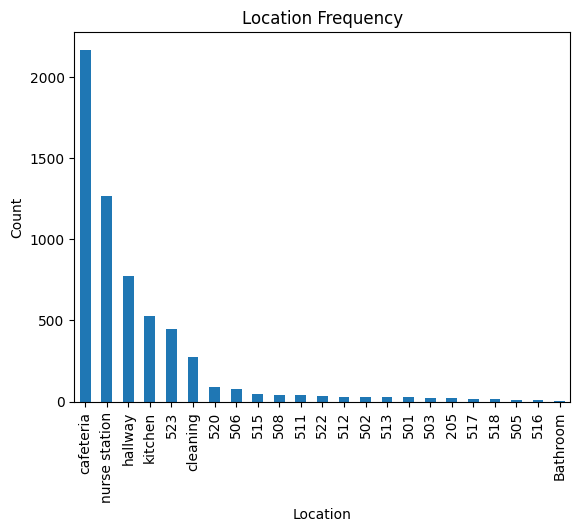

In [4]:
df['location'].value_counts().plot(kind='bar')
plt.title('Location Frequency')
plt.xlabel('Location')
plt.ylabel('Count')

# 3. Train a random forest model

In [5]:
y = df['location']
X = df.drop(columns='location')
X.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_std,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count
0,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
1,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
2,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7
3,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9
4,0,0,0,136,17,0,34,0,47,0,...,1.247755,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11


In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [7]:
split_idx = int(0.7 * len(X))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y_encoded[:split_idx]
y_test  = y_encoded[split_idx:]

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", X.columns)
    ]
)

In [9]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [10]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.2f}")
print(f"F1 score: {f1:.2f}")

Accuracy: 0.94
F1 score: 0.15


In [12]:
transformed_feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
feature_importances = pipeline.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                     Feature  Importance
43  num__unique_beacon_count    0.120887
25         num__first_beacon    0.050125
32              num__b1_norm    0.045245
31               num__b1_min    0.043503
28              num__b1_mean    0.038204
8               num__count_9    0.032651
30               num__b1_max    0.031951
29               num__b1_std    0.028894
3               num__count_4    0.028068
18             num__count_19    0.027024
37              num__b2_norm    0.026490
13             num__count_14    0.023539
42              num__b3_norm    0.023309
15             num__count_16    0.023308
16             num__count_17    0.022912
36               num__b2_min    0.022497
33              num__b2_mean    0.022285
5               num__count_6    0.021919
22             num__count_23    0.021701
14             num__count_15    0.021145
40               num__b3_max    0.021134
34               num__b2_std    0.020013
7               num__count_8    0.018978
27         num__